In [5]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import torch
import random
import numpy as np
from tqdm import tqdm
#import numpy
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.tensorboard import SummaryWriter  
import pdb
import matplotlib.pyplot as plt # for ploting graph and chart
from sklearn.preprocessing import label_binarize # convert labels into binary format needed for multiclass classification
from sklearn.metrics import roc_curve, auc, f1_score, recall_score, precision_score, confusion_matrix # performance evaluation metrics
from dataset_test import read_data
import seaborn as sns
import pandas as pd

import torchvision

#from MHT import ViFNet
from  torchvision.models.mobilenetv3 import mobilenet_v3_large, MobileNet_V3_Large_Weights
from functools import partial








In [6]:
# Function to initialize weights
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
            
            
# Function to reset the classifier
def reset_classifier(model, num_classes):
    model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes, bias=True) if num_classes > 0 else nn.Identity()
    
    model.classifier[-1].apply(init_weights)


In [7]:


def test_loop(dataloader, model, loss_fn, device):
    model.eval()  # initialize the model in evaluation mode
    size = len(dataloader.dataset)
    pbar = tqdm(dataloader, total=int(len(dataloader)))
    count = 0
    test_loss = 0.0
    test_acc = 0.0

    label_all = []
    outputs_all = []
    sample_names = []

    # Iterate through the data, computes the loss and accuracy, and record predictions
    with torch.no_grad():
        for batch, sample in enumerate(pbar):
            x, labels, names = sample  # assuming read_data function returns (data, labels, names)
            sample_names.extend(names)  # store sample names

            label_all.append(labels.numpy())
            x, labels = x.to(device), labels.to(device)

            outputs = model(x)
            loss = loss_fn(outputs, labels)
            _, pred = torch.max(outputs, 1)
            num_correct = (pred == labels).sum()

            loss = loss.item()
            acc = num_correct.item() / len(labels)
            count += len(labels)
            test_loss += loss * len(labels)
            test_acc += num_correct.item()
            pbar.set_description(f"loss: {loss:>f}, acc: {acc:>f}, [{count:>d}/{size:>d}]")

            outputs_all.append(outputs.detach().cpu().numpy())

    label_all = np.concatenate(label_all)
    outputs_all = np.concatenate(outputs_all)

    # return the average test loss, test accuracy, labels, outputs, and sample names
    return test_loss / count, test_acc / count, label_all, outputs_all, sample_names
















 

Device: cuda
MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stri

loss: 0.348972, acc: 0.950820, [1725/1725]: 100%|██████████| 27/27 [00:01<00:00, 14.43it/s]



Test loss: 0.318956, acc: 0.943768

Precision: 0.931100, recall: 0.927689, f1: 0.928833
Class 0 - Precision: 0.85, Recall: 0.77, F1 Score: 0.81
Class 1 - Precision: 0.98, Recall: 0.98, F1 Score: 0.98
Class 2 - Precision: 0.96, Recall: 0.97, F1 Score: 0.97
Class 3 - Precision: 0.92, Recall: 0.92, F1 Score: 0.92
Class 4 - Precision: 0.97, Recall: 0.95, F1 Score: 0.96
Class 5 - Precision: 0.91, Recall: 0.97, F1 Score: 0.93
Confusion Matrix:
[[123   1   1  11   7  17]
 [  1 451   1   1   3   4]
 [  0   2 115   0   1   0]
 [  9   2   0 172   0   3]
 [  5   5   3   1 460   8]
 [  6   1   0   2   2 307]]


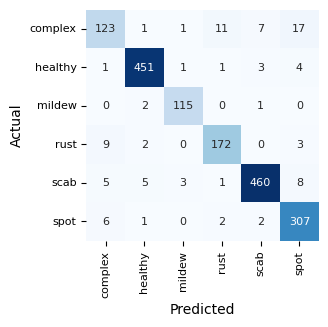

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Misclassified Samples:
Sample: complex/e89f82785f091de1.jpg, True Class: 0, Predicted Class: 3
Sample: complex/c3b555e0aed194cc.jpg, True Class: 0, Predicted Class: 5
Sample: complex/de1cda2ec91ca41e.jpg, True Class: 0, Predicted Class: 4
Sample: complex/cd27ce297630c761.jpg, True Class: 0, Predicted Class: 5
Sample: complex/ca782c131f5ce0fc.jpg, True Class: 0, Predicted Class: 3
Sample: complex/fa5e87e2386c86c2.jpg, True Class: 0, Predicted Class: 2
Sample: complex/b4af82b18fd24ac9.jpg, True Class: 0, Predicted Class: 5
Sample: complex/96e313a663998f49.jpg, True Class: 0, Predicted Class: 4
Sample: complex/d76939c0e1c761e4.jpg, True Class: 0, Predicted Class: 5
Sample: complex/bf8fdcf0dc2060b0.jpg, True Class: 0, Predicted Class: 5
Sample: complex/939760c29c3eb5b8.jpg, True Class: 0, Predicted Class: 5
Sample: complex/e52d3fc23ac57085.jpg, True Class: 0, Predicted Class: 5
Sample: complex/bc8d94cad7cb2b02.jpg, True Class: 0, Predicted Class: 5
Sample: complex/849780fbfb4b2d41.jpg, Tru

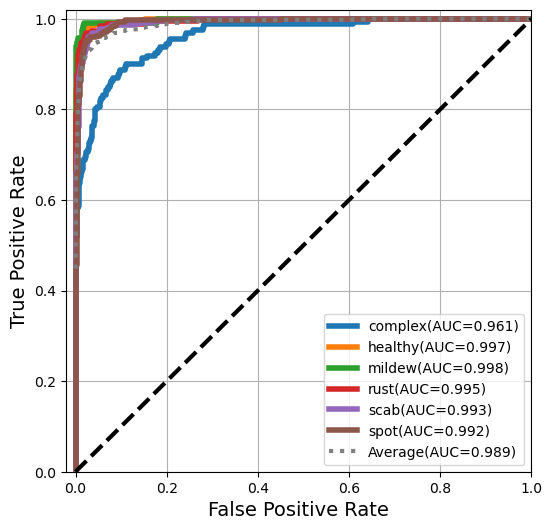

In [8]:
   
if __name__ == '__main__':
    # check if CUDA is available for GPU acceleration
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print('Device:', device)

    # directories setup
    save_dir = './HD_384_B_6'
    data_dir = '/DATA/ishwar_2221cs30/Work_2/Apple2021/data'
    batchsize = 64

    # data loading using read_data function
    _, test_generator = read_data(batchsize, data_dir)

    # load model architecture
     # Load the pre-trained Swin Transformer model
    model = mobilenet_v3_large(weights= MobileNet_V3_Large_Weights.DEFAULT, progress=True) 


    # Reset the classifier for the new task with, for example, 10 classes

    reset_classifier(model, num_classes=6)         

    model = model.to(device)
    # load model weight from a saved state
    model.load_state_dict(torch.load(os.path.join(save_dir, 'acc_model.pth')))

    # print model and parameter details
    print(model)
    print("There are", sum(p.numel() for p in model.parameters()), "parameters.")
    print("There are", sum(p.numel() for p in model.parameters() if p.requires_grad), "trainable parameters.")

    # loss function
    criterion = nn.CrossEntropyLoss().to(device)

    # calling the test_loop
    test_loss, test_acc, y_test, y_score, sample_names = test_loop(test_generator, model, criterion, device)

    # compute and print various metrics
    print("\nTest loss: {:f}, acc: {:f}".format(test_loss, test_acc))
    y_pred = y_score.argmax(axis=-1)
    f1 = f1_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    precision = precision_score(y_test, y_pred, average='macro')
    print("\nPrecision: {:f}, recall: {:f}, f1: {:f}".format(precision, recall, f1))

    # Calculate precision, recall, and F1 score for each class
    precision_per_class = precision_score(y_test, y_pred, average=None)
    recall_per_class = recall_score(y_test, y_pred, average=None)
    f1_per_class = f1_score(y_test, y_pred, average=None)

    # Print results
    for i in range(len(precision_per_class)):
        print(f"Class {i} - Precision: {precision_per_class[i]:.2f}, Recall: {recall_per_class[i]:.2f}, F1 Score: {f1_per_class[i]:.2f}")

    # Calculate the confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print('Confusion Matrix:')
    print(conf_matrix)

    cm_df = pd.DataFrame(conf_matrix, index= ["complex", "healthy", "mildew", "rust", "scab", "spot"] , columns=["complex", "healthy", "mildew", "rust", "scab", "spot"] )
    # Plotting
    plt.figure(figsize=(3, 3))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 8}, cbar=False)
    #sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 12}, cbar=False, linewidths=.5, linecolor='black')

    #plt.title('Confusion Matrix Heatmap')
    plt.ylabel('Actual', fontsize=10)
    plt.xlabel('Predicted', fontsize = 10)

    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    plt.show()







     #print result
    # Print misclassified samples
    misclassified_samples = [ (name, true, pred) for name, true, pred in zip(sample_names, y_test, y_pred) if true != pred]
    print('Misclassified Samples:')
    for name, true, pred in misclassified_samples:
        # Extract only the last two parts of the path
        short_name = "/".join(name.split("/")[-2:])
        print(f'Sample: {short_name}, True Class: {true}, Predicted Class: {pred}')

    # Binary classification and ROC curve computation
    y_test = label_binarize(y_test, classes=[0, 1, 2, 3, 4, 5])
    n_classes = 6
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    class_names = ["complex", "healthy", "mildew", "rust", "scab", "spot"]
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    plt.figure(figsize=(6, 6))
    colors = ['C0', 'C1', 'C2','C3', 'C4', 'C5']
    for i, color in zip([0, 1, 2, 3, 4, 5], colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=4,
                 label=class_names[i] + '(AUC=%.3f)' % roc_auc[i])

    fpr_grid = np.linspace(0.0, 1.0, 1000)
    # Interpolate all ROC curves at these points
    mean_tpr = np.zeros_like(fpr_grid)

    for i in range(n_classes):
        mean_tpr += np.interp(fpr_grid, fpr[i], tpr[i])  # linear interpolation
    mean_tpr /= n_classes

    fpr["macro"] = fpr_grid
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    plt.plot(
        fpr["macro"],
        tpr["macro"],
        label=f"Average(AUC={roc_auc['macro']:.3f})",
        color='C7',
        linestyle=":",
        linewidth=3,
    )
    plt.plot([0, 1], [0, 1], 'k--', lw=3)
    plt.xlim([-0.02, 1.0])
    plt.ylim([0.0, 1.02])
    plt.xlabel('False Positive Rate', fontsize=14)
    plt.ylabel('True Positive Rate', fontsize=14)
    #plt.title('Receiver operating characteristic for multi-class data')
    plt.legend(loc="lower right", fontsize=10)
    plt.tick_params(labelsize=10)
    plt.rcParams.update({'font.size': 10})
    plt.grid()

    plt.savefig('auc.eps', format='eps', bbox_inches='tight')
    plt.show()
    
    
